# K-Means 聚类

**课程 0011 配套练习** · 内核：`deeplearning`

前置：课程 0003（距离）。前 10 课全是**有监督**学习（有标签）。这一课进入**无监督**：只有数据，没有标签，让算法自己发现「这堆数据里有几个团」。K-Means 是最经典的聚类，面试必考。

> 读完后请回答：为什么「分配 + 更新」两步必然收敛，却只保证局部最优？

## 问题设定：四团数据

我们『作弊』地知道真实有 4 个簇（其实无监督时不知道）——用它来验证算法能不能找回真相。

X: (300, 2) 真实簇数: 4


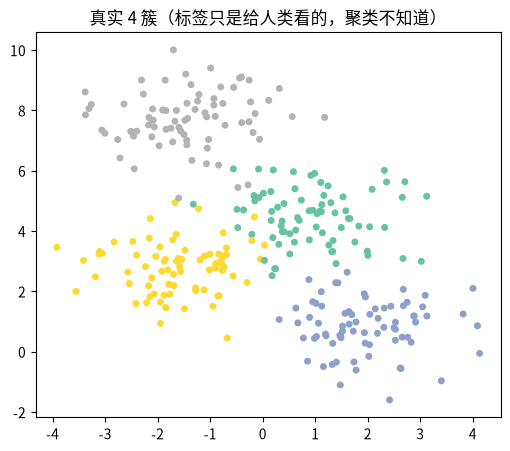

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# matplotlib 中文字体
import matplotlib as mpl
from matplotlib import font_manager
for name in ["Noto Sans CJK SC", "Noto Serif CJK SC", "WenQuanYi Zen Hei", "SimHei"]:
    if any(f.name == name for f in font_manager.fontManager.ttflist):
        mpl.rcParams["font.sans-serif"] = [name]
        break
mpl.rcParams["axes.unicode_minus"] = False

from sklearn.datasets import make_blobs

X, y_true = make_blobs(n_samples=300, centers=4, cluster_std=0.9, random_state=0)
print("X:", X.shape, "真实簇数:", len(np.unique(y_true)))

plt.figure(figsize=(6, 5))
plt.scatter(X[:, 0], X[:, 1], c=y_true, cmap="Set2", s=16)
plt.title("真实 4 簇（标签只是给人类看的，聚类不知道）")
plt.show()

## 手写 K-Means（Lloyd 迭代）

三步：随机初始化 k 个质心 → 循环「分配」（点到最近质心）→「更新」（质心=组内均值）。返回 (标签, 质心)。

簇大小： [75 78 74 73]


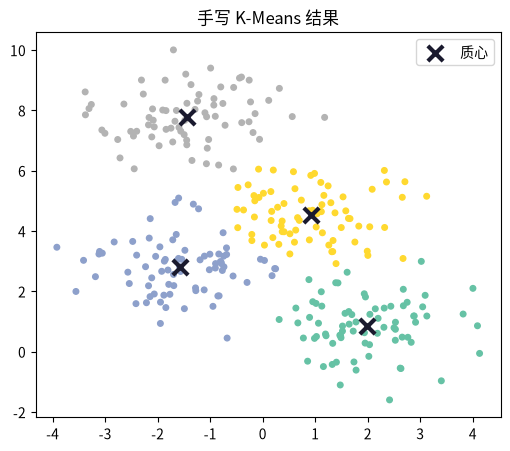

In [ ]:
def kmeans(X, k, iters=50, seed=0):
    """手写 K-Means。返回 (labels, centers)。"""
    rng = np.random.default_rng(seed)
    idx = rng.choice(len(X), k, replace=False)
    centers = X[idx].copy()
    for _ in range(iters):
        d = ((X[:, None, :] - centers[None, :, :]) ** 2).sum(-1)   # (n, k) 距离平方, k是质心个数
        labels = d.argmin(1)                                        # 分配：最近质心
        # 这里argmin(1)返回的是每一行最小值的索引，也就是每个样本点对应的质心索引，(n, 1)的数组
        new = np.array([
            X[labels == j].mean(0) if (labels == j).any() else centers[j]
            for j in range(k)
        ])  # 更新k个质心
        if np.allclose(new, centers):                               # 收敛
            # Returns True if two arrays are element-wise equal within a tolerance.
            break
        centers = new
    return labels, centers

labels, centers = kmeans(X, 4, seed=0)
print("簇大小：", np.bincount(labels))

plt.figure(figsize=(6, 5))
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap="Set2", s=16)
plt.scatter(centers[:, 0], centers[:, 1], marker="x", c="#1a1a2e", s=120, lw=3, label="质心")
plt.legend(); plt.title("手写 K-Means 结果")
plt.show()

## 验证收敛：SSE 单调不降

类内平方和 SSE = Σ（每个点到其质心的距离²）。每轮「分配」「更新」都只让它变小，所以曲线单调下降、必然收敛。

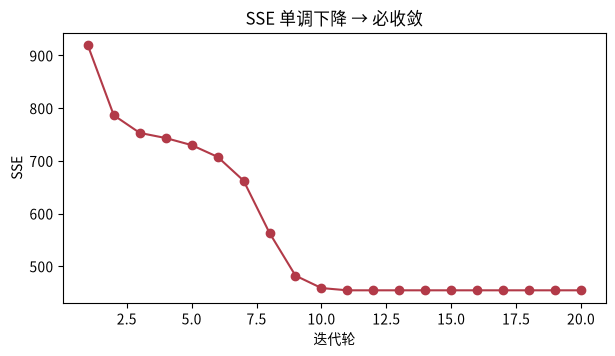

In [ ]:
def sse(X, labels, centers):
    return float(np.sum((X - centers[labels]) ** 2))# 这里sum是全部元素求和，得到所有样本的簇内平方误差总和。
# X - centers[labels]  # (n, d) - (n, d){centers:(k, d)但是这里是centers[labels]，所以元素个数由len(labels)决定, 变为(n, d) } = (n, d)

sse_history = []
rng = np.random.default_rng(0)
idx = rng.choice(len(X), 4, replace=False)
centers0 = X[idx].copy()
for it in range(20):
    d = ((X[:, None, :] - centers0[None, :, :]) ** 2).sum(-1)   # (n, k) 距离平方, k是质心个数
    labels0 = d.argmin(1)   # (n, 1):分配：最近质心
    centers0 = np.array([X[labels0 == j].mean(0) if (labels0 == j).any() else centers0[j] for j in range(4)])       # 更新k个质心, (k, d), d是特征维度
    sse_history.append(sse(X, labels0, centers0))

plt.figure(figsize=(7, 3.5))
plt.plot(range(1, len(sse_history) + 1), sse_history, "o-", color="#b23a48")
plt.xlabel("迭代轮"); plt.ylabel("SSE"); plt.title("SSE 单调下降 → 必收敛")
plt.show()

## sklearn 版 + 肘部法选 k

sklearn 的 `KMeans` 和手写一致（还自动多次初始化）。肘部法：SSE 随 k 增大而减小，找「拐点」——k=4 之后收益骤减。

sklearn SSE： 454.4 （与手写一致）


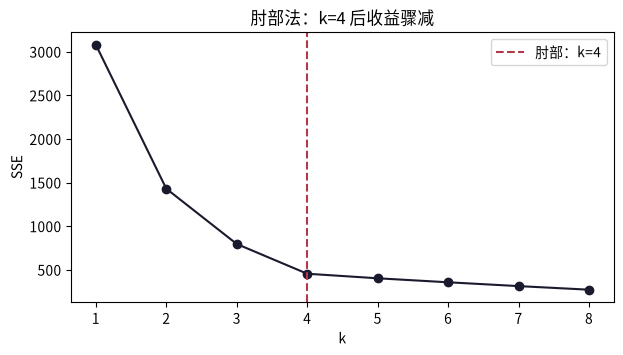

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

km = KMeans(n_clusters=4, n_init=10, random_state=0).fit(X)
print("sklearn SSE：", round(km.inertia_, 1), "（与手写一致）")

# 肘部法
sse_list = [KMeans(n_clusters=k, n_init=10, random_state=0).fit(X).inertia_ for k in range(1, 9)]
plt.figure(figsize=(7, 3.5))
plt.plot(range(1, 9), sse_list, "o-", color="#1a1a2e")
plt.axvline(4, ls="--", color="#b23a48", label="肘部：k=4")
# 遍历不同的聚类数 k，画出 k‑SSE 曲线，找图像发生拐点（手肘），拐点对应的 k 就是推荐聚类数目。
plt.xlabel("k"); plt.ylabel("SSE"); plt.legend()
plt.title("肘部法：k=4 后收益骤减")
plt.show()

## 轮廓系数：另一种选 k

轮廓系数看每个样本「贴自己组还是贴别组」，平均后 ∈ [−1, 1]。k=4 处峰值 → 数据确实像 4 个团。

轮廓系数： {2: 0.466, 3: 0.484, 4: 0.537, 5: 0.467, 6: 0.408}


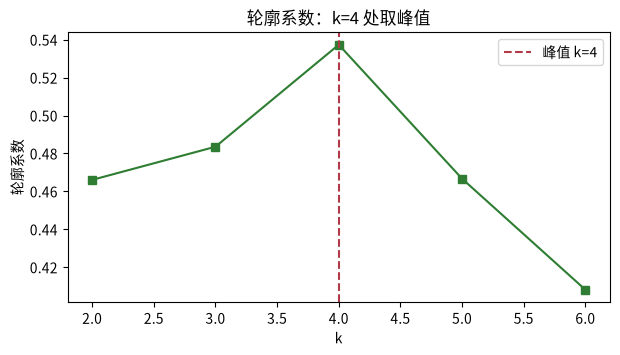

In [ ]:
k_range = range(2, 7)
sil = [silhouette_score(X, KMeans(n_clusters=k, n_init=10, random_state=0).fit_predict(X)) for k in k_range]    # Compute the mean Silhouette Coefficient of all samples.
print("轮廓系数：", {k: round(v, 3) for k, v in zip(k_range, sil)})

plt.figure(figsize=(7, 3.5))
plt.plot(list(k_range), sil, "s-", color="#2e7d32")
plt.axvline(4, ls="--", color="#b23a48", label="峰值 k=4")
plt.xlabel("k"); plt.ylabel("轮廓系数"); plt.legend()
plt.title("轮廓系数：k=4 处取峰值")
plt.show()

## K-Means 的短板：拉长的簇

K-Means 用欧氏距离、认「圆」。把数据沿 y 轴拉伸成「长条」，它就开始犯浑。

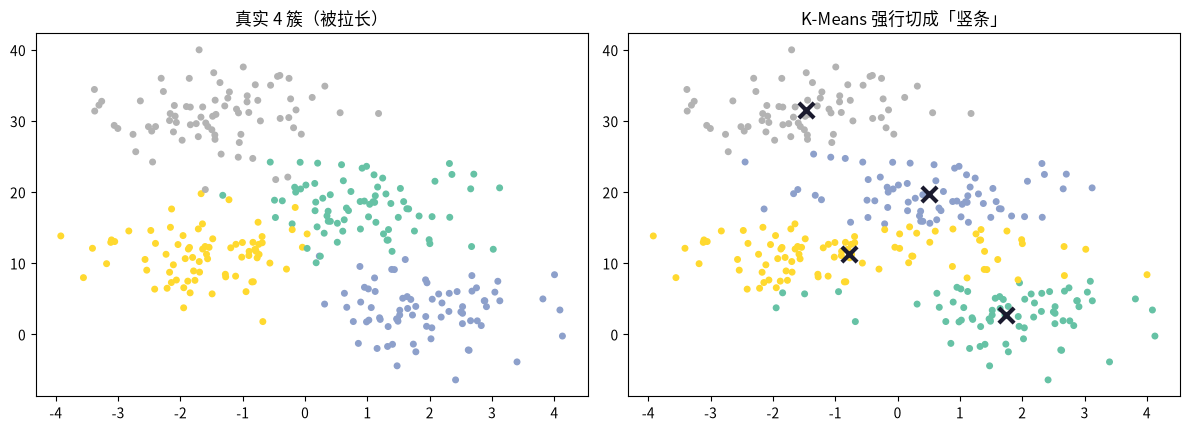

真实 vs 聚类：拉长后 K-Means 边界画成竖条，把真实簇从中间切开


In [ ]:
X_stretch = np.c_[X[:, 0], X[:, 1] * 4]      # 纵向拉成 4 倍，就是单独把y轴拉长(乘上4)，x轴不变。
# np.c_ 相当于 np.concatenate((X[:, 0], X[:, 1] * 4), axis=1)，把两个列向量拼接成一个矩阵，第一列是原来的第一列，第二列是原来的第二列乘以4。
labels_s, centers_s = kmeans(X_stretch, 4, seed=0)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))
axes[0].scatter(X_stretch[:, 0], X_stretch[:, 1], c=y_true, cmap="Set2", s=16)
axes[0].set_title("真实 4 簇（被拉长）")
axes[1].scatter(X_stretch[:, 0], X_stretch[:, 1], c=labels_s, cmap="Set2", s=16)
axes[1].scatter(centers_s[:, 0], centers_s[:, 1], marker="x", c="#1a1a2e", s=120, lw=3)
axes[1].set_title("K-Means 强行切成「竖条」")
plt.tight_layout(); plt.show()
print("真实 vs 聚类：拉长后 K-Means 边界画成竖条，把真实簇从中间切开")

## 练习（S 理解 / M 动手 / H 挑战）

**S1.** 为什么「分配 + 更新」两步循环一定收敛？SSE 曲线为什么单调下降？如果中途不变了，说明什么？

**S2.** 肘部法和轮廓系数给同一个 k 吗？如果真实簇数你不知道（无监督现实），你会怎么交叉验证自己的选择？

**M1.** 用不同的 `seed`（如 0~9）跑 `kmeans(X, 4, seed=s)`，比较 10 次结果的 SSE。一样吗？最小的那个说明什么？

**M2.** 把数据换成 `make_blobs(cluster_std=3.0)`（各簇散开很大、互相重叠），肘部法的「拐点」还明显吗？轮廓系数还可靠吗？

**H1.** 拉长的簇失败——根子在「模型」（距离度量/圆形假设）还是「算法」（迭代）？换成高斯混合模型（GMM）或对特征先缩放/标准化能救吗？试试 `StandardScaler` 后重跑。

**H2.** 面试题：K-Means 的「K」和「Means」分别指什么？为什么需要多次 `n_init`？说说至少两个 K-Means 的改进/变体（如 k-means++、mini-batch K-Means）。

In [ ]:
# pass  # 练习区（S1/S2）
# 单调有界必收敛

# 二者不一定给出相同 k。无监督没有标签，不能用普通准确率；可以结合肘部法、轮廓系数，看聚类结果业务解释性，多次改变随机种子观察聚类稳定性，也可以用 BIC/AIC 辅助筛选。

In [ ]:
# pass  # 练习区（M1/M2）
# sklearn 的n_init就是多次随机初始化，自动保留 SSE 最小那套结果。

# 肘部法、轮廓系数都比较适合簇分离良好、近球形的数据；簇严重重叠时，两个指标效果都变差。

In [ ]:
# pass  # 练习区（H1/H2）
# K‑means 使用欧氏距离，隐含假设：簇是球形、各向同性。

# K 是簇的数量，Means 代表簇用均值做中心；n_init 多次随机初始化，规避局部最优；常见变体 k‑means++ 优化初始化，Mini‑batch K‑Means 针对大数据加速。